In [9]:
import numpy as np
import pandas as pd
import MetaTrader5 as mt5
import time
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import ta

In [2]:
# INITIALIZE THE DEVICE
mt5.initialize()

# Create empty lists
symbols = []
sectors = []
descriptions = []
trade=[]

# Get the information for all symbol
symbols_information = mt5.symbols_get()

# Tuple to list
symbols_information_list = list(symbols_information)

print(symbols_information_list[0])

# Extract the name of the symbol
for element in symbols_information_list:
     if list(element)[-3] in ('USDJPYm','BTCUSDm','XAUUSDm'):
        symbols.append(list(element)[-3])
        sectors.append(list(element)[-1].split("\\")[0])
        descriptions.append(list(element)[-7])
        trade.append(bool(list(element)[16]))
    
# Create a dataframe
informations = pd.DataFrame([symbols, sectors, descriptions,trade], index=["Symbol", "Sector", "Description","Trade"]).transpose()


# Create empty list
spread = []

# Computze the spread
for symbol in informations["Symbol"]:
    try:
        ask =  mt5.symbol_info_tick(symbol).ask
        bid =  mt5.symbol_info_tick(symbol).bid
        spread.append((ask - bid) / bid )
        
    except:
        spread.append(None)

# Take the assets with the spread < 0.07%
informations["Spread"] = spread
lowest_spread_asset = informations

SymbolInfo(custom=False, chart_mode=0, select=True, visible=True, session_deals=0, session_buy_orders=0, session_sell_orders=0, volume=0, volumehigh=0, volumelow=0, time=1754074691, digits=5, spread=81, spread_float=True, ticks_bookdepth=0, trade_calc_mode=0, trade_mode=0, start_time=0, expiration_time=0, trade_stops_level=0, trade_freeze_level=0, trade_exemode=2, swap_mode=0, swap_rollover3days=3, margin_hedged_use_leg=False, expiration_mode=15, filling_mode=3, order_mode=127, order_gtc_mode=0, option_mode=0, option_right=0, bid=3.67272, bidhigh=3.67277, bidlow=3.6721399999999997, ask=3.67353, askhigh=3.67361, asklow=3.67297, last=0.0, lasthigh=0.0, lastlow=0.0, volume_real=0.0, volumehigh_real=0.0, volumelow_real=0.0, option_strike=0.0, point=1e-05, trade_tick_value=0.2722177306296668, trade_tick_value_profit=0.2722177306296668, trade_tick_value_loss=0.2722777668866671, trade_tick_size=1e-05, trade_contract_size=100000.0, trade_accrued_interest=0.0, trade_face_value=0.0, trade_liquid

In [3]:
lowest_spread_asset=lowest_spread_asset[lowest_spread_asset["Trade"]]

In [4]:
lowest_spread_asset

,Symbol,Sector,Description,Trade,Spread
0,BTCUSDm,Standard,Bitcoin vs US Dollar,True,0.000188
1,USDJPYm,Standard,US Dollar vs Japanese Yen,True,0.000706
2,XAUUSDm,Standard,Gold vs US Dollar,True,0.000048


In [5]:
def get_data(symbol, n, timeframe=mt5.TIMEFRAME_H4):
    """ Function which returns the data of the symbol"""

    # Initialize MetaTrader device
 
    
    # Put the data in a dataframe
    utc_from = datetime.now()+timedelta(hours=2)
    rates = mt5.copy_rates_from(symbol, timeframe, utc_from,n) 
    rates_frame = pd.DataFrame(rates)
    
    # Convert time in seconds into the datetime format 
    rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
    rates_frame['time'] =  pd.to_datetime(rates_frame['time'], format='%Y-%m-%d')
    rates_frame = rates_frame.set_index('time')
    
    return rates_frame

In [6]:
def features_engineering(df):
    """ This function which creates all the necessary sets for the algorithms"""

    # Allows the variables to be call outside the function
    global X_train
    global X_test
    global y_train_reg
    global y_train_cla 
    global X_train_scaled 
    global X_test_scaled
    global split_train_test
    global split_test_valid
    global X_valid
    global X_valid_scaled
    global X_train_pca
    global X_test_pca
    global X_val_pca


    # Create ours own metrics to compute the strategy returns
    df["returns"] = ((df["close"] - df["close"].shift(1)) / df["close"])
    df["sLow"] = ((df["low"] - df["close"].shift(1)) / df["close"].shift(1))
    df["sHigh"] = ((df["high"] - df["close"].shift(1)) / df["close"].shift(1))

    # Features engineering
    df["returns t-1"] = df[["returns"]].shift(1)

    # Mean of returns
    df["mean returns 15"] = df[["returns"]].rolling(15).mean().shift(1)
    df["mean returns 60"] = df[["returns"]].rolling(60).mean().shift(1)

    # Volatility of returns
    df["volatility returns 15"] = df[["returns"]].rolling(15).std().shift(1)
    df["volatility returns 60"] = df[["returns"]].rolling(60).std().shift(1)

    # Drop missing values
    df = df.dropna()
    
    # Percentage train set
    split = int(0.80*len(df))
   

   
    list_x = ["returns t-1", "mean returns 15", "mean returns 60",
                  "volatility returns 15",
                  "volatility returns 60"]


    split_train_test = int(0.70*len(df))
    split_test_valid = int(0.90*len(df))

    # Train set creation
    X_train = df[list_x].iloc[:split_train_test]

    y_train_reg = df[["returns"]].iloc[:split_train_test]

    y_train_cla = np.round(df[["returns"]].iloc[:split_train_test]+0.5)


    # Test set creation
    X_test = df[list_x].iloc[split_train_test:split_test_valid]
    
    # Test set creation
    X_val = df[list_x].iloc[split_test_valid:]


    # NORMALIZATION 
    # Import the class
    from sklearn.preprocessing import StandardScaler

    # Initialize the class
    sc = StandardScaler()

    # Standardize the data
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)
    X_val_scaled = sc.transform(X_val)
    
    
    
    
    
    # PCA
    # Import the class
    from sklearn.decomposition import PCA
    
    # Initiliaze the class
    pca = PCA(n_components=3)
    
    # Apply the PCA
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_val_pca = pca.transform(X_val_scaled)
   

In [7]:
def predictor(df, model, reg=True, spread = 0.035):
    model.fit(X_train_pca, y_train_cla)


    df = df.dropna()
    # Create predictions for the whole dataset
    df["prediction"] = model.predict(np.concatenate((X_train_pca,X_test_pca, X_val_pca),
                                        axis=0))

    if reg==False:
        df["prediction"] = np.where(df["prediction"]==0, -1, 1)

    df["prediction"] = df.prediction
    df=df.dropna()
    # Compute the strategy
    df["strategy"] = df["prediction"]* df["returns"]

    returns = df["strategy"].iloc[split_train_test:split_test_valid]

    return np.sqrt(252) * (returns.mean()-(spread/100))/ returns.std()

In [8]:
# Imports
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from tqdm import tqdm

# Model instances
tree       = DecisionTreeClassifier(max_depth=6)
svr        = SVC(C=1.5)
lin        = LogisticRegression()
mlp        = MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', max_iter=200)
randomf    = RandomForestClassifier(n_estimators=200, max_depth=8)
gradientb  = GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)
xgb_clf    = xgb.XGBClassifier(learning_rate=0.1, n_estimators=200)

# (name, model, reg_flag) — reg=True means regression, reg=False means classification
models = [
    ("Tree",       tree,      True),
    ("SVR",        svr,       False),
    ("LinReg",     lin,       False),
    ("MLP",        mlp,       False),
    ("RandomForest", randomf, False),
    ("GradBoost",  gradientb, False),
    ("XGBoost",    xgb_clf,   False),
]

# Backtest loop
symbols = lowest_spread_asset["Symbol"]
results = []  # will hold [symbol, model_name, sharpe, data_length]

for symbol in tqdm(symbols):
    try:
        # 1) Fetch and prepare data
        df = get_data(symbol, 70000).dropna()
        df["returns"] = (df["close"] - df["close"].shift(1)) / df["close"].shift(1)
        features_engineering(df)

        # 2) Run each model through your predictor()
        for name, mdl, is_reg in models:
            sharpe = predictor(df, mdl, reg=is_reg)
            results.append([symbol, name, sharpe, len(df)])

    except Exception as e:
        print(f"Issue with {symbol}: {e}")

# 3) Aggregate into DataFrame and inspect top performers
import pandas as pd
results_df = pd.DataFrame(results, columns=["Symbol", "Model", "Sharpe", "Length"])
top35 = results_df[results_df["Length"]>600].sort_values("Sharpe", ascending=False).head(35)
print(top35)


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:47<00:00, 35.91s/it]

     Symbol         Model    Sharpe  Length
4   BTCUSDm  RandomForest -0.124126   16370
3   BTCUSDm           MLP -0.297359   16370
1   BTCUSDm           SVR -0.335173   16370
5   BTCUSDm     GradBoost -0.451458   16370
6   BTCUSDm       XGBoost -0.546917   16370
0   BTCUSDm          Tree -0.565870   16370
2   BTCUSDm        LinReg -0.630855   16370
15  XAUUSDm           SVR -0.865210   14401
18  XAUUSDm  RandomForest -1.216840   14401
20  XAUUSDm       XGBoost -1.328328   14401
19  XAUUSDm     GradBoost -1.481630   14401
16  XAUUSDm        LinReg -1.542940   14401
17  XAUUSDm           MLP -1.732201   14401
12  USDJPYm     GradBoost -1.840458   14474
9   USDJPYm        LinReg -1.871008   14474
11  USDJPYm  RandomForest -1.918287   14474
14  XAUUSDm          Tree -1.924748   14401
8   USDJPYm           SVR -1.940937   14474
13  USDJPYm       XGBoost -2.001691   14474
10  USDJPYm           MLP -2.114674   14474
7   USDJPYm          Tree -2.148435   14474


In [9]:
results = pd.DataFrame(lists, columns=["Symbol", "Model", "Sharpe", "Lenght"])
results_copy=results.copy()

results.sort_values(by="Sharpe", ascending=False).loc[results["Lenght"]>600].head(35).drop_duplicates(subset=['Symbol'])
print(lists)

[['BTCAUDm', 'Tree', np.float64(0.2888638548151419), 1553], ['BTCAUDm', 'SVR', np.float64(-0.0725100852543843), 1553], ['BTCAUDm', 'LinReg', np.float64(0.43563768580889445), 1553], ['BTCCNHm', 'Tree', np.float64(-0.38962811941805403), 1552], ['BTCCNHm', 'SVR', np.float64(-0.6767690966591433), 1552], ['BTCCNHm', 'LinReg', np.float64(0.04542531948135686), 1552], ['BTCTHBm', 'Tree', np.float64(-0.418445192558851), 1552], ['BTCTHBm', 'SVR', np.float64(-0.31035118062082256), 1552], ['BTCTHBm', 'LinReg', np.float64(-0.2674255012505696), 1552], ['BTCXAGm', 'Tree', np.float64(-0.09347631596731246), 1553], ['BTCXAGm', 'SVR', np.float64(0.2526673879204686), 1553], ['BTCXAGm', 'LinReg', np.float64(-0.3436128236880961), 1553], ['BTCXAUm', 'Tree', np.float64(0.8869678563248435), 1553], ['BTCXAUm', 'SVR', np.float64(-0.11831258829438121), 1553], ['BTCXAUm', 'LinReg', np.float64(-1.06791738505973), 1553], ['BTCZARm', 'Tree', np.float64(0.09958717318975649), 1553], ['BTCZARm', 'SVR', np.float64(-1.038

In [10]:
print(results.sort_values(by="Sharpe", ascending=False).loc[results["Sharpe"].astype(float)>0].head(35))

      Symbol   Model    Sharpe  Lenght
350  USDTRYm  LinReg  2.600073    3500
565      MSm     SVR  2.450878    1381
531     JPMm    Tree  2.163753    1381
456     BACm    Tree  2.137273    1381
349  USDTRYm     SVR  2.116748    3500
62   AUDSEKm  LinReg  2.069867    3500
532     JPMm     SVR  2.032017    1381
460    BIIBm     SVR  2.000719    1119
688    YUMCm     SVR  1.944681     947
564      MSm    Tree  1.934390    1381
633     WMTm    Tree  1.915036    1381
701  XNIUSDm  LinReg  1.901518     612
348  USDTRYm    Tree  1.875359    3500
533     JPMm  LinReg  1.840417    1381
578    NVDAm  LinReg  1.825403    1381
477    COSTm    Tree  1.798949    1120
697  XCUUSDm     SVR  1.735520     529
630     WFCm    Tree  1.707089    1381
301  TRYDKKm     SVR  1.705610    3500
457     BACm     SVR  1.692777    1381
176  EURTRYm  LinReg  1.662659    3500
555     MMMm    Tree  1.630751    1120
572    NFLXm  LinReg  1.624013    1378
114  CHFTRYm    Tree  1.618910    3500
698  XCUUSDm  LinReg  1.6

In [15]:
liste_retenu=[  "EDUm", "BIIBm","AUDSEKm","JPMm","NVDAm","METAm","XNGUSDm","NFLXm"]

In [16]:
def voting(df, reg=True):    
    """ Create a strategy using a voting method"""
    # Import the class
   
    
    # Import the models
    if reg:
        tree = DecisionTreeRegressor(max_depth=6)
        svr = SVR(epsilon=1.5)
        lin = LinearRegression()
        vot = VotingRegressor(estimators=[
            ('lr', lin), ("tree", tree), ("svr", svr)])
    else:
        tree = DecisionTreeClassifier(max_depth=6)
        svr = SVC()
        lin = LogisticRegression()

        vot = VotingClassifier(estimators=[
            ('lr', lin), ("tree", tree), ("svr", svr)])

    # Train the model
    if reg==False:
        vot.fit(X_train_pca, y_train_cla)
    else:
        vot.fit(X_train_pca, y_train_reg)

    # Remove missing values 
    df = df.dropna()
    
    # Create predictions for the whole dataset
    df["prediction"] = vot.predict(np.concatenate((X_train_pca,
                                                   X_test_pca,
                                                   X_val_pca),
                                        axis=0))
    
    # Remove missing values 
    df = df.dropna()
    
    if reg==False:
        df["prediction"] = np.where(df["prediction"]==0, -1, 1)

    # Compute the strategy
    df["strategy"] = np.sign(df["prediction"]) * df["returns"]
    df["low_strategy"] = np.where(df["prediction"]>0, df["sLow"], -df["sHigh"])
    df["high_strategy"] = np.where(df["prediction"]>0, df["sHigh"], -df["sLow"])


    return vot, df["strategy"], df["low_strategy"], df["high_strategy"]

In [17]:
mt5.initialize()

# Import the class
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.ensemble import VotingRegressor, VotingClassifier
import pickle
from joblib import dump, load

# Initialization
lists = []
res = pd.DataFrame()
low_assets = pd.DataFrame()
high_assets = pd.DataFrame()

for symbol in liste_retenu:
    print(symbol)
    
    
    # Import the data
    df = get_data(symbol, 3500).dropna()
    
    # Create ours own metrics to compute the strategy returns
    df["returns"] = ((df["close"] - df["close"].shift(1)) / df["close"])
    df["sLow"] = ((df["low"] - df["close"].shift(1)) / df["close"].shift(1))
    df["sHigh"] = ((df["high"] - df["close"].shift(1)) / df["close"].shift(1))
    # Remove missing values
    df = df.dropna()
    
    # Create the sets
    features_engineering(df)

    # Compute the strategy
    vot, res[symbol],low_assets[symbol],high_assets[symbol] = voting(df, reg=False)

    # Save the model
    s = pickle.dumps(vot)
    alg = pickle.loads(s)

    dump(alg ,f"Models/{symbol}_voting.joblib")

EDUm
BIIBm
AUDSEKm
JPMm
NVDAm
METAm
XNGUSDm
NFLXm


<Axes: xlabel='time'>

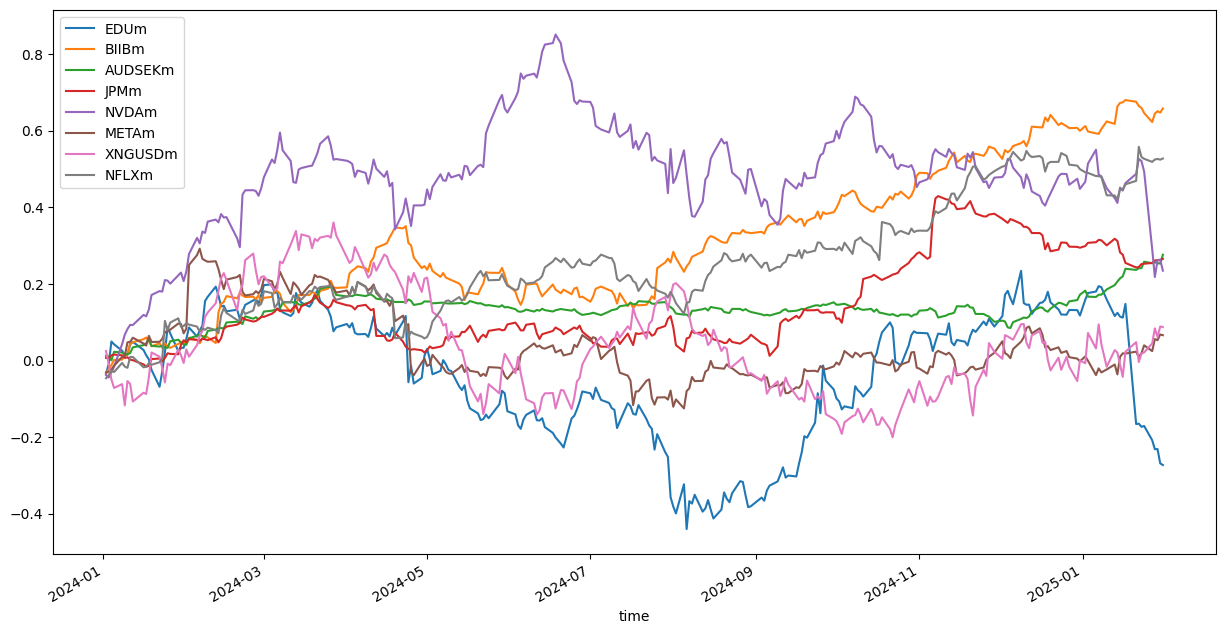

In [18]:
# Display cumulative returns of the strategies on the test set
data = res.dropna().loc["2024-01":"2025-01"]
data.cumsum().plot(figsize=(15,8))

In [19]:
from scipy.optimize import minimize
import numpy as np
import pandas as pds



def SOR_criterion(weight, data):
    """ 
    -----------------------------------------------------------------------------
    | Output: Opposite Sortino ratio to do a m imization                        |
    -----------------------------------------------------------------------------
    | Inputs: -Weight (type ndarray numpy): Wheight for portfolio               |
    |         -data (type dataframe pandas): Returns of stocks                  |
    -----------------------------------------------------------------------------
    """
    # Compute portfolio returns
    portfolio_return = np.multiply(data, np.transpose(weight))
    portfolio_return = portfolio_return.sum(axis=1)

    # Compute mean, volatility of the portfolio
    mean = np.mean(portfolio_return, axis=0)
    std = np.std(portfolio_return[portfolio_return < 0], axis=0)

    # Compute the opposite of the Sharpe ratio
    Sortino = mean / std
    Sortino = -Sortino
    return Sortino


def MV_criterion(weights, data):
    """
    -----------------------------------------------------------------------------
    | Output: optimization porfolio criterion                                   |
    -----------------------------------------------------------------------------
    | Inputs: -weight (type ndarray numpy): Wheight for portfolio               |
    |         -data (type ndarray numpy): Returns of stocks                     |
    -----------------------------------------------------------------------------
    """

    # Parameters
    Lambda = 3
    W = 1
    Wbar = 1 + 0.25 / 100

    # Compute portfolio returns
    portfolio_return = np.multiply(data, np.transpose(weights))
    portfolio_return = portfolio_return.sum(axis=1)

    # Compute mean and volatility of the portfolio
    mean = np.mean(portfolio_return, axis=0)
    std = np.std(portfolio_return, axis=0)

    # Compute the criterion
    criterion = Wbar ** (1 - Lambda) / (1 + Lambda) + Wbar ** (-Lambda) \
                * W * mean - Lambda / 2 * Wbar ** (-1 - Lambda) * W ** 2 * std ** 2
    criterion = -criterion
    return criterion

def SK_criterion(weights, data):
    """ 
    -----------------------------------------------------------------------------
    | Output: optimization porfolio criterion                                   |
    -----------------------------------------------------------------------------
    | Inputs: -weight (type ndarray numpy): Wheight for portfolio               |
    |         -data (type ndarray numpy): Returns of stocks                     |
    -----------------------------------------------------------------------------
    """
    from scipy.stats import skew, kurtosis
    # Parameters
    Lambda = 3
    W = 1
    Wbar = 1 + 0.25 / 100

    # Compute portfolio returns
    portfolio_return = np.multiply(data, np.transpose(weights))
    portfolio_return = portfolio_return.sum(axis=1)

    # Compute mean, volatility, skew, kurtosis of the portfolio
    mean = np.mean(portfolio_return, axis=0)
    std = np.std(portfolio_return, axis=0)
    skewness = skew(portfolio_return, 0)
    kurt = kurtosis(portfolio_return, 0)

    # Compute the criterion
    criterion = Wbar ** (1 - Lambda) / (1 + Lambda) + Wbar ** (-Lambda) \
    * W * mean - Lambda / 2 * Wbar ** (-1 - Lambda) * W ** 2 * std ** 2 \
    + Lambda * (Lambda + 1) / (6) * Wbar ** (-2 - Lambda) * W ** 3 * skewness \
    - Lambda * (Lambda + 1) * (Lambda + 2) / (24) * Wbar ** (-3 - Lambda) *\
     W ** 4 * kurt
    
    criterion = -criterion
    return criterion


def optimization_portfolio(criterion, data):

    # Find the number of asset
    n=data.shape[1]

    # Initialisation weight value
    x0 = np.ones(n)

    # Optimization constraints problem
    cons=({'type':'eq', 'fun': lambda x:sum(abs(x))-1})

    # Set the bounds
    Bounds= [(0 , 1) for i in range(0,n)]


    # Optimization problem solving
    res_SK = minimize(criterion, x0, method="SLSQP",
                      args=(data),bounds=Bounds,
                      constraints=cons,options={'disp': True})

    # Result for computations
    X = res_SK.x
    return X

In [20]:
#Backtext
import pandas as pd
import yfinance as yf
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib as mpl


def backtest_static_portfolio(weights, database, ben="^GSPC", timeframe=252, CR=False):
    """
    -----------------------------------------------------------------------------
    | Output: Beta CAPM metric                                                  |
    -----------------------------------------------------------------------------
    | Inputs: - weights (type 1d array numpy): weights of the portfolio         |
    |         - database (type dataframe pandas): Returns of the asset          |
    |         - ben (type string): Name of the benchmark                        |
    |         - timeframe (type int): annualization factor                      |
    -----------------------------------------------------------------------------
    """
    import pandas as pd
    import yfinance as yf
    import numpy as np
    from scipy.optimize import minimize
    import matplotlib.pyplot as plt


    # Compute the portfolio
    portfolio = np.multiply(database,np.transpose(weights))
    portfolio = portfolio.sum(axis=1)
    columns = database.columns
    columns = [col for col in columns]

    ######################### COMPUTE THE BETA ##################################
    # Importation of benchmark
    benchmark = yf.download(ben)["Close"].pct_change(1).dropna()

    # Concat the asset and the benchmark
    join = pd.concat((portfolio, benchmark), axis=1).dropna()

    # Covariance between the asset and the benchmark
    cov = np.cov(join, rowvar=False)[0][1]

    # Compute the variance of the benchmark
    var = np.cov(join, rowvar=False)[1][1]

    beta = cov/var


    ######################### COMPUTE THE ALPHA #################################
    # Mean of returns for the asset
    mean_stock_return = join.iloc[:,0].mean()*timeframe

    # Mean of returns for the market
    mean_market_return = join.iloc[:,1].mean()*timeframe

    # Alpha
    alpha = mean_stock_return - beta*mean_market_return


    ######################### COMPUTE THE SHARPE ################################
    mean = portfolio.mean() * timeframe
    std = portfolio.std() * np.sqrt(timeframe)
    Sharpe = mean/std


    ######################### COMPUTE THE SORTINO ###############################
    downward = portfolio[portfolio<0]
    std_downward = downward.std() * np.sqrt(timeframe)
    Sortino = mean/std_downward


    ######################### COMPUTE THE DRAWDOWN ###############################
    # Compute the cumulative product returns
    cum_rets = (portfolio+1).cumprod()

    # Compute the running max
    running_max = np.maximum.accumulate(cum_rets.dropna())
    running_max[running_max < 1] = 1

    # Compute the drawdown
    drawdown = ((cum_rets)/running_max - 1)
    min_drawdon = -drawdown.min()


    ######################### COMPUTE THE VaR ##################################
    theta = 0.01
    # Number of simulations
    n = 100000

    # Find the values for theta% error threshold
    t = int(n*theta)

    # Create a vector with n simulations of the normal law
    vec = pd.DataFrame(np.random.normal(mean, std, size=(n,)),
    columns = ["Simulations"])

    # Orderer the values and find the theta% value
    VaR = -vec.sort_values(by="Simulations").iloc[t].values[0]


    ######################### COMPUTE THE cVaR #################################
    cVaR = -vec.sort_values(by="Simulations").iloc[0:t,:].mean().values[0]

    ######################### COMPUTE THE RC ###################################
    if CR:
        # Find the number of the asset in the portfolio
        l = len(weights)

        # Compute the risk contribution of each asset
        crs = []
        for i in range(l):
            # Importation of benchmark
            benchmark = yf.download(ben)["Close"].pct_change(1).dropna()

            # Concat the asset and the benchmark
            join = pd.concat((database.iloc[:,i], benchmark), axis=1).dropna()

            # Covariance between the asset and the benchmark
            cov = np.cov(join, rowvar=False)[0][1]

            # Compute the variance of the benchmark
            var = np.cov(join, rowvar=False)[1][1]
            beta_s = cov/var
            cr = beta_s * weights[i]
            crs.append(cr)
            crs_ = crs/np.sum(crs) # Normalizing by the sum of the risk contribution

    ######################### PLOT THE RESULTS #################################
    print(f"""
    -----------------------------------------------------------------------------
    Portfolio: {columns}
    -----------------------------------------------------------------------------
    Beta: {np.round(beta, 3)} \t Alpha: {np.round(alpha*100, 2)} %\t \
    Sharpe: {np.round(Sharpe, 3)} \t Sortino: {np.round(Sortino, 3)}
    -----------------------------------------------------------------------------
    VaR: {np.round(VaR*100, 2)} %\t cVaR: {np.round(cVaR*100, 2)} % \t \
    VaR/cVaR: {np.round(cVaR/VaR, 3)} \t drawdown: {np.round(min_drawdon*100, 2)} %
    -----------------------------------------------------------------------------
    """)

    plt.figure(figsize=(15,8))
    plt.plot(join.iloc[:,0].cumsum()*100, color="#035593", linewidth=3)
    plt.plot(join.iloc[:,1].cumsum()*100, color="#068C72", linewidth=3)
    plt.title("CUMULTATIVE RETURN", size=15)
    plt.ylabel("Cumulative return %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    ##plt.legend(["Strategy", "Benchmark"])
    plt.savefig(f'Cum.svg', format='svg', dpi=1200)
    plt.show()

    plt.figure(figsize=(15,8))
    plt.fill_between(drawdown.index, drawdown*100, 0, color="#CE5151")
    plt.plot(drawdown.index,drawdown*100, color="#930303", linewidth=1.5)
    plt.title("DRAWDOWN", size=15)
    plt.ylabel("Drawdown %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.savefig(f'drawdown.svg', format='svg', dpi=1200)
    plt.show()



    if CR:
        plt.figure(figsize=(15,8))
        plt.scatter(columns, crs_, linewidth=3, color = "#B96553")
        plt.axhline(0, color="#53A7B9")
        plt.grid(axis="x")
        plt.title("RISK CONTRIBUTION PORTFOLIO", size=15)
        plt.xlabel("Assets")
        plt.ylabel("Risk contribution")
        plt.xticks(size=15,fontweight="bold")
        plt.yticks(size=15,fontweight="bold")
        plt.savefig(f'CR.svg', format='svg', dpi=1200)
        plt.show()
        plt.show()


def backtest_dynamic_portfolio(dfc, ben="^GSPC", timeframe=252):
  """
  -----------------------------------------------------------------------------
  | Output: Beta CAPM metric                                                  |
  -----------------------------------------------------------------------------
  | Inputs: - weights (type 1d array numpy): weights of the portfolio         |
  |         - database (type dataframe pandas): Returns of the asset          |
  |         - ben (type string): Name of the benchmark                        |
  |         - timeframe (type int): annualization factor                      |
  -----------------------------------------------------------------------------
  """
  import pandas as pd
  import yfinance as yf
  import numpy as np
  from scipy.optimize import minimize
  import matplotlib.pyplot as plt
  import matplotlib as mpl
  import matplotlib.pyplot as plt

  from matplotlib import cycler


  font = {'weight' : 'bold', "size":"300"}
  plt.rc('font', **font)

  # Maybe from series to dataframe
  if str(type(dfc)) == "<class 'pandas.core.series.Series'>":
    dfc = pd.DataFrame(dfc)
    
  # find the returns
  if len(dfc.columns)==1:
    dfc.columns=["returns"]
    

  # CREATE DAILY RETURNS
  portfolio = dfc["returns"]
  if portfolio.index.name != "Time":
      portfolio.index.name = "Time"


  portfolio = portfolio.reset_index(drop=False)
  portfolio.groupby(pd.Grouper(key='Time',freq='d')).sum()
  portfolio = portfolio.set_index("Time")
  ######################### COMPUTE THE BETA ##################################
  # Importation of benchmark
  benchmark = yf.download(ben)["Close"].pct_change(1).dropna()

  # Concat the asset and the benchmark
  join = pd.concat((portfolio, benchmark), axis=1).dropna()

  # Covariance between the asset and the benchmark
  cov = np.cov(join, rowvar=False)[0][1]

  # Compute the variance of the benchmark
  var = np.cov(join, rowvar=False)[1][1]

  beta = cov/var


  ######################### COMPUTE THE ALPHA #################################
  # Mean of returns for the asset
  mean_stock_return = join.iloc[:,0].mean()*timeframe

  # Mean of returns for the market
  mean_market_return = join.iloc[:,1].mean()*timeframe

  # Alpha
  alpha = mean_stock_return - beta*mean_market_return


  ######################### COMPUTE THE SHARPE ################################
  mean = portfolio.mean() * np.sqrt(timeframe)
  std = portfolio.std() 
  Sharpe = (mean/std)[0]


  ######################### COMPUTE THE SORTINO ###############################
  downward = portfolio[portfolio<0]* np.sqrt(timeframe)
  std_downward = downward.std()
  Sortino = (mean/std_downward)[0]


  ######################### COMPUTE THE DRAWDOWN ###############################
  # Compute the cumulative product returns
  coef_rets = (portfolio+1).cumprod()
  cum_rets = coef_rets-1

  # Compute the running max
  running_max = np.maximum.accumulate(coef_rets.dropna())
  #running_max[running_max < 1] = 1

  # Compute the drawdown
  drawdown = ((coef_rets/running_max) - 1)
  min_drawdon = (-drawdown.min())[0]


  ######################### COMPUTE THE VaR ##################################
  theta = 0.01
  # Number of simulations
  n = 100000
  
  # Find the values for theta% error threshold
  t = int(n*theta)

  # Create a vector with n simulations of the normal law
  vec = pd.DataFrame(np.random.normal(mean, std, size=(n,)),columns = ["Simulations"])
  
  # Orderer the values and find the theta% value
  VaR = -vec.sort_values(by="Simulations").iloc[t].values[0]


  ######################### COMPUTE THE cVaR #################################
  cVaR = -vec.sort_values(by="Simulations").iloc[0:t,:].mean().values[0]

  ######################### TIME UNDERWATER ##################################
  tuw = len(drawdown[drawdown<0]) / len(drawdown)

  ######################### PLOT THE RESULTS #################################
  print(f"""
    -----------------------------------------------------------------------------
    Beta: {np.round(beta, 3)} \t Alpha: {np.round(alpha*100, 2)} %\t \
    Sharpe: {np.round(Sharpe, 3)} \t Sortino: {np.round(Sortino, 3)}
  -----------------------------------------------------------------------------
    VaR: {np.round(VaR*100, 2)} %\t cVaR: {np.round(cVaR*100, 2)} % \t \
    VaR/cVaR: {np.round(cVaR/VaR, 3)} \t drawdown: {np.round(min_drawdon*100, 2)} %
  -----------------------------------------------------------------------------""")
  

  plt.figure(figsize=(15,8))
  plt.plot(join.iloc[:,0].cumsum()*100, color="#035593", linewidth=3)
  plt.plot(join.iloc[:,1].cumsum()*100, color="#068C72", linewidth=3)
  plt.title("CUMULTATIVE RETURN", size=15)
  plt.ylabel("Cumulative return %", size=15)
  plt.xticks(size=15,fontweight="bold")
  plt.yticks(size=15,fontweight="bold")
  plt.legend(["Strategy", "Benchmark"])
  plt.show()

  plt.figure(figsize=(15,8))
  plt.fill_between(drawdown.index, drawdown.iloc[:,0]*100, 0, color="#CE5151")
  plt.plot(drawdown.index,drawdown.iloc[:,0]*100, color="#930303", linewidth=3)
  plt.title("DRAWDOWN", size=15)
  plt.ylabel("Drawdown %", size=15)
  plt.xticks(size=15,fontweight="bold")
  plt.yticks(size=15,fontweight="bold")
  plt.show()

def backtest_tpsl_portfolio(dfc, ben="^GSPC", timeframe=252):

    """
    -----------------------------------------------------------------------------
    | Output: Backtest                                                          |
    -----------------------------------------------------------------------------
    | Inputs: - database (type dataframe pandas): data of the asset          |
    |         - ben (type string): Name of the benchmark                        |
    |         - timeframe (type int): annualization factor                      |
    -----------------------------------------------------------------------------
    """
    # COMPUTE TRADE LIFETIME
    sum_dates = dfc["duration"]
    seconds = np.round(np.mean(list(sum_dates.loc[sum_dates!=0])).total_seconds())
    minutes = seconds//60
    minutes_left = int(minutes%60)
    hours = int(minutes//60)

    # CREATE DAILY RETURNS
    portfolio = dfc["returns"]
    if portfolio.index.name != "Time":
        portfolio.index.name = "Time"


    portfolio = portfolio.reset_index(drop=False)
    portfolio.groupby(pd.Grouper(key='Time',freq='d')).sum()
    portfolio = portfolio.set_index("Time")

    ######################### COMPUTE THE BETA ##################################
    # Importation of benchmark
    benchmark = yf.download(ben)["Close"].pct_change(1).dropna()

    # Concat the asset and the benchmark
    join = pd.concat((portfolio[["returns"]], benchmark), axis=1).dropna()

    # Covariance between the asset and the benchmark
    cov = np.cov(join, rowvar=False)[0][1]

    # Compute the variance of the benchmark
    var = np.cov(join, rowvar=False)[1][1]

    beta = cov/var

    ######################### COMPUTE THE ALPHA #################################
    # Mean of returns for the asset
    mean_stock_return = join.iloc[:,0].mean()*timeframe

    # Mean of returns for the market
    mean_market_return = join.iloc[:,1].mean()*timeframe

    # Alpha
    alpha = mean_stock_return - beta*mean_market_return

    ######################### COMPUTE THE SHARPE ################################
    mean = portfolio.mean() * np.sqrt(timeframe)
    std = portfolio.std() 
    Sharpe = (mean/std)[0]


    ######################### COMPUTE THE SORTINO ###############################
    downward = portfolio[portfolio<0]* np.sqrt(timeframe)
    std_downward = downward.std()
    Sortino = (mean/std_downward)[0]


    ######################### COMPUTE THE DRAWDOWN ###############################
    # Compute the cumulative product returns
    coef_rets = (portfolio+1).cumprod()
    cum_rets = coef_rets-1

    # Compute the running max
    running_max = np.maximum.accumulate(coef_rets.dropna())
    #running_max[running_max < 1] = 1

    # Compute the drawdown
    drawdown = ((coef_rets/running_max) - 1)
    min_drawdon = (-drawdown.min())[0]

    ######################### COMPUTE THE VaR ##################################
    theta = 0.01
    # Number of simulations
    n = 100000

    # Find the values for theta% error threshold
    t = int(n*theta)

    # Create a vector with n simulations of the normal law
    vec = pd.DataFrame(np.random.normal(mean, std, size=(n,)),columns = ["Simulations"])

    # Orderer the values and find the theta% value
    VaR = -vec.sort_values(by="Simulations").iloc[t].values[0]


    ######################### COMPUTE THE cVaR #################################
    cVaR = -vec.sort_values(by="Simulations").iloc[0:t,:].mean().values[0]

    ######################### TIME UNDERWATER ##################################
    tuw = len(drawdown[drawdown["returns"]<0]) / len(drawdown)
    
    ######################### PLOT THE RESULTS #################################
    print(f"""
    -----------------------------------------------------------------------------
    Beta: {np.round(beta, 3)} \t Alpha: {np.round(alpha*100, 2)} %\t \
    AVERAGE TRADE LIFETIME: {hours}H {minutes_left}min
    -----------------------------------------------------------------------------
    VaR: {np.round(VaR*100, 2)} %\t cVaR: {np.round(cVaR*100, 2)} % \t \
    TUW: {np.round(tuw*100,2)}%  \t drawdown: {np.round(min_drawdon*100, 2)} %
    -----------------------------------------------------------------------------""")

    plt.figure(figsize=(15,8))
    plt.plot(cum_rets*100, color="#035593", linewidth=3)
    plt.plot(join.iloc[:,1].cumsum()*100, color="#068C72", linewidth=3)
    plt.title("CUMULTATIVE RETURN", size=15)
    plt.ylabel("Cumulative return %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.legend(["Strategy", "Benchmark"])
    plt.show()

    plt.figure(figsize=(15,8))
    plt.fill_between(drawdown.index, drawdown.iloc[:,0]*100, 0, color="#CE5151")
    plt.plot(drawdown.index,drawdown.iloc[:,0]*100, color="#930303", linewidth=3)


    plt.title("DRAWDOWN", size=15)
    plt.ylabel("Drawdown %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.show()

Inequality constraints incompatible    (Exit mode 4)
            Current function value: nan
            Iterations: 1
            Function evaluations: 9
            Gradient evaluations: 1
[1. 1. 1. 1. 1. 1. 1. 1.]
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



    -----------------------------------------------------------------------------
    Beta: 1.426 	 Alpha: 405.04 %	     Sharpe: 3.327 	 Sortino: 0.324
  -----------------------------------------------------------------------------
    VaR: -7.97 %	 cVaR: -5.4 % 	     VaR/cVaR: 0.678 	 drawdown: 83.72 %
  -----------------------------------------------------------------------------


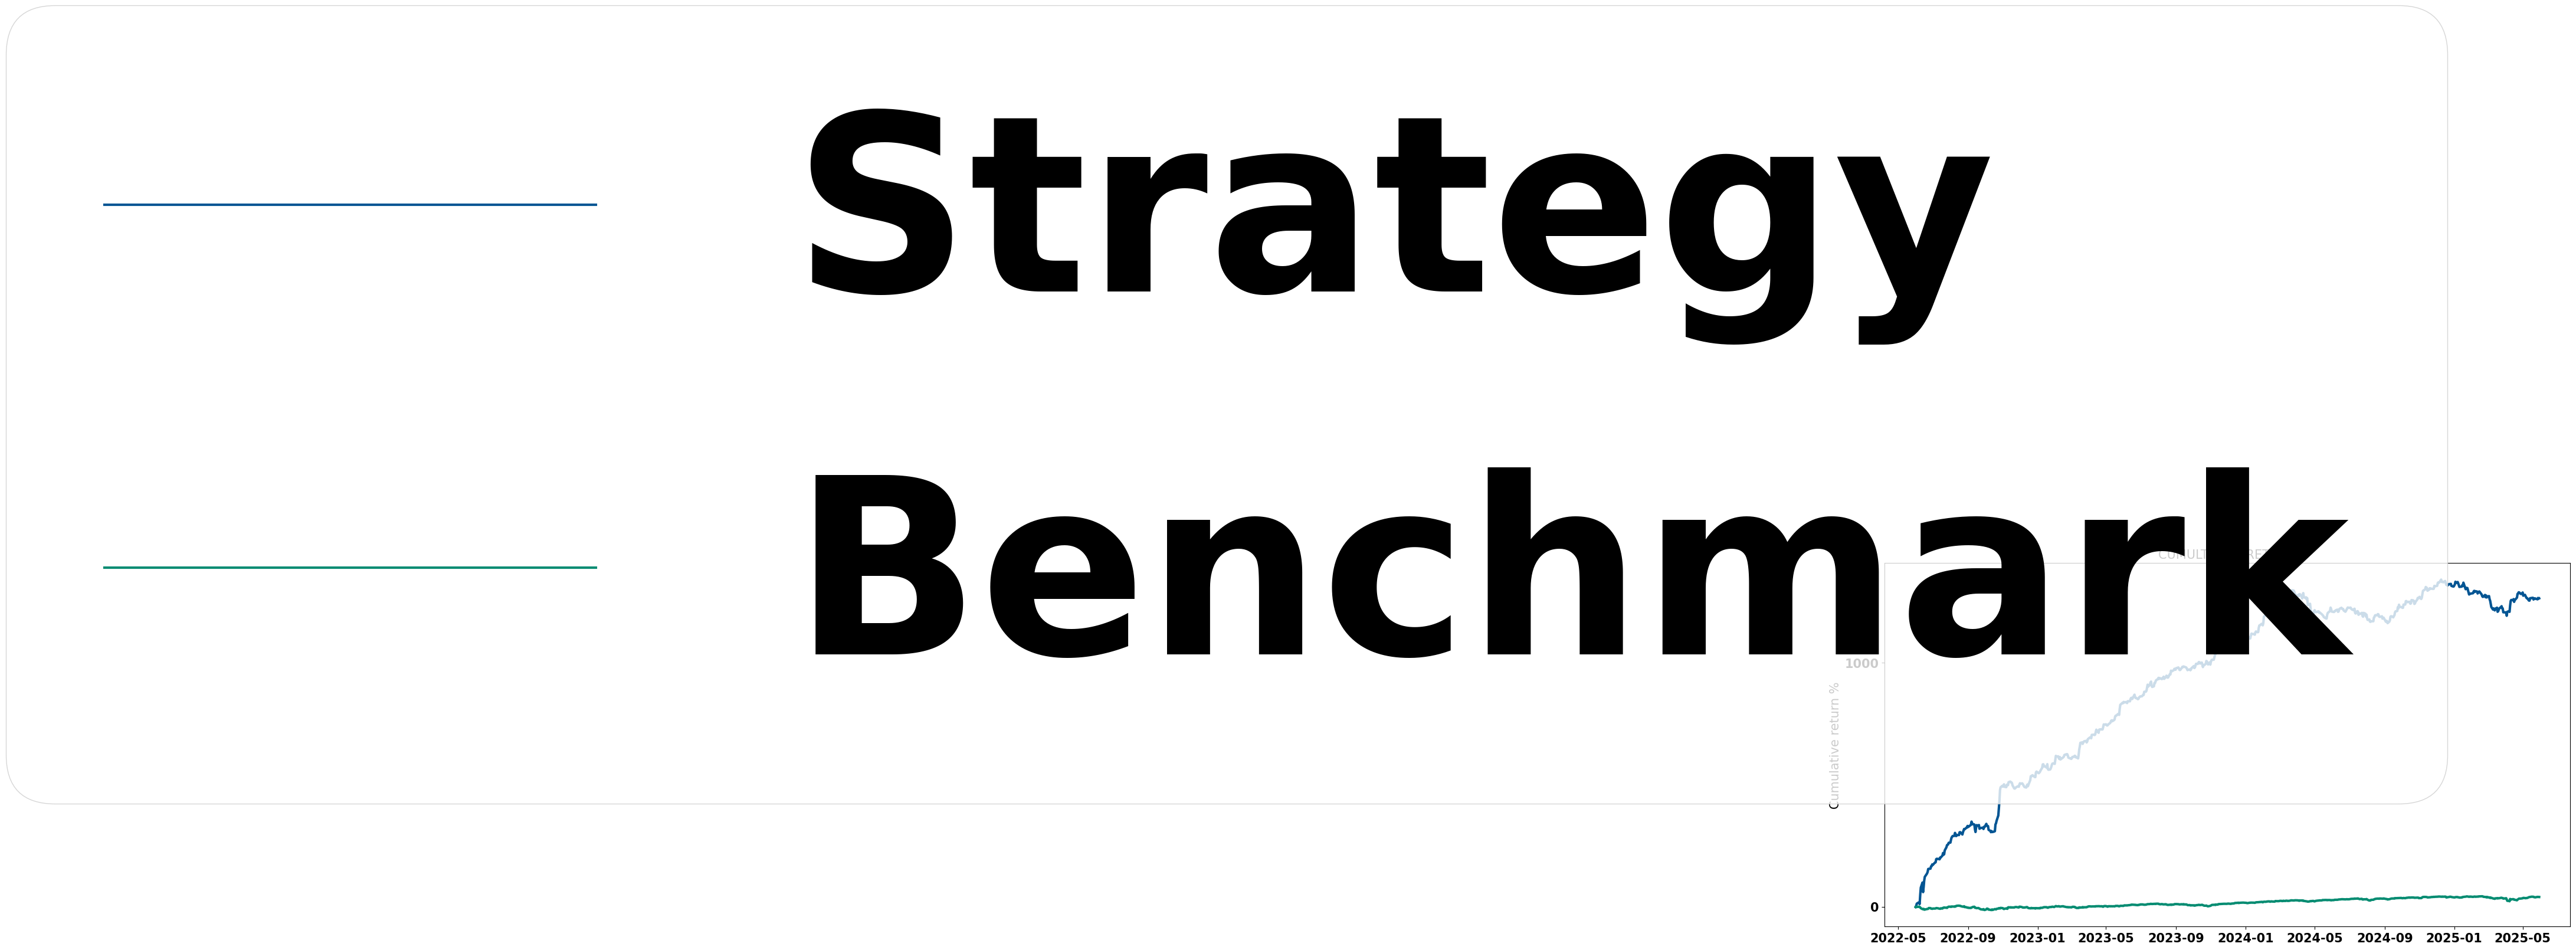

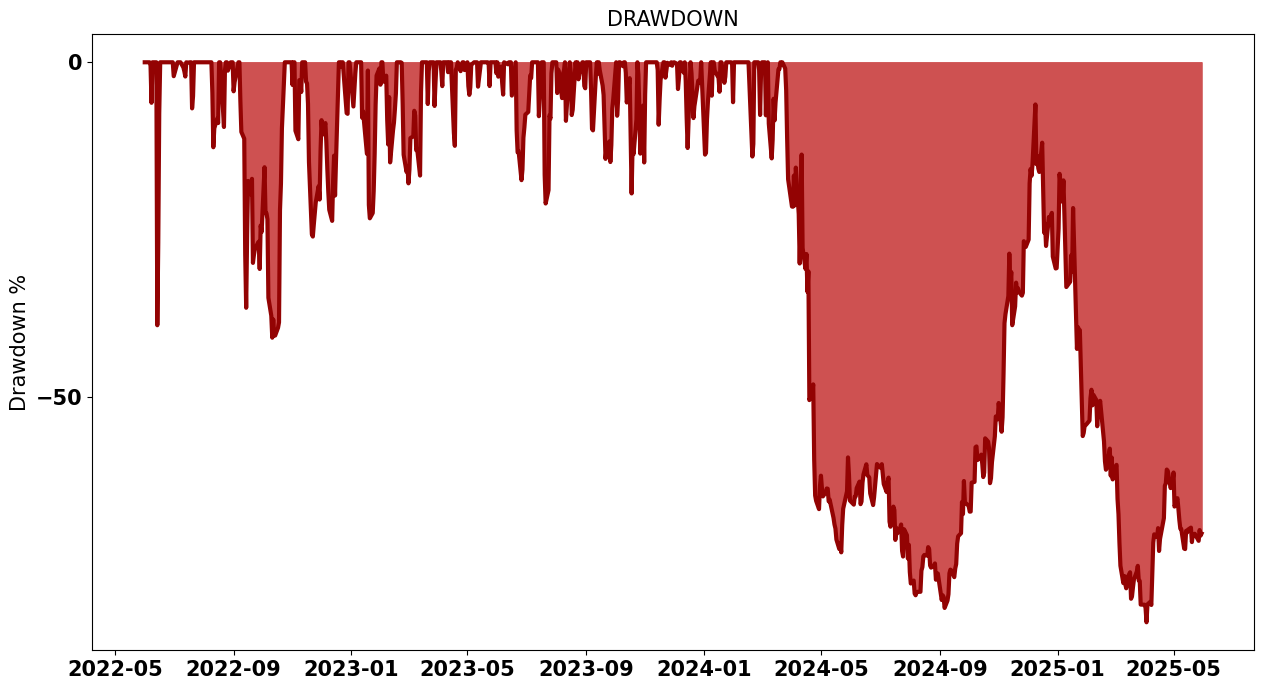

In [21]:
data = res.dropna().loc["2020-01":"2021-01"]
val = res.dropna().loc["2021-01":]

X = optimization_portfolio(MV_criterion, data)

print(np.round(X,3))

spread = 0.001
low_portfolio = np.multiply(low_assets,np.transpose(X)).sum(axis=1)
high_portfolio = np.multiply(high_assets,np.transpose(X)).sum(axis=1)


# Compute the cumulative return of the portfolio (CM)
portfolio_return_test = np.multiply(data,np.transpose(X)).sum(axis=1)
portfolio_return_MV = np.multiply(val,np.transpose(X)).sum(axis=1)

backtest_dynamic_portfolio(portfolio_return_MV)

In [22]:
def find_best_tp(tp):
    tp = tp/100
    
    # Create the portfolio
    pf = pd.concat((low_portfolio, portfolio_return_test,high_portfolio), axis=1).dropna()-spread
    pf.columns = ["low", "Return", "high"]

    # Apply the tp
    pf["Return"] = np.where(pf["high"].values>tp, tp, pf["Return"].values)
    pf["Return"] = np.where(pf["Return"].values>tp, tp, pf["Return"].values)
    down = pf["Return"].values
    down = down[down<0]
    
    # Return sharpe raatio
    return np.sqrt(252)*pf["Return"].mean()/down.std()

pd.DataFrame([find_best_tp(tp) for tp in np.linspace(0.2,10,30)],  index=np.linspace(0.2,10,30), columns=["Sharpe"])

,Sharpe
0.200000,NaN
0.537931,NaN
0.875862,NaN
1.213793,NaN
1.551724,NaN
1.889655,NaN
2.227586,NaN
2.565517,NaN
2.903448,NaN
3.241379,NaN


In [ ]:
tp = 0.5/100
pf = pd.concat((low_portfolio, portfolio_return_MV,high_portfolio), axis=1).dropna()-spread
pf.columns = ["low", "Return", "high"]

pf["Return"] = np.where(pf["high"].values>tp, tp, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values>tp, tp, pf["Return"].values)

backtest_dynamic_portfolio(pf["Return"])

In [ ]:
 def find_best_sl(sl):
    sl = sl/100
    
    # Create the portfolio
    pf = pd.concat((low_portfolio, portfolio_return_test,high_portfolio), axis=1).dropna()-spread
    pf.columns = ["low", "Return", "high"]

    # Apply the tp
    pf["Return"] = np.where(pf["low"].values<-sl, -sl, pf["Return"].values)
    pf["Return"] = np.where(pf["Return"].values<-sl, -sl, pf["Return"].values)
    
    # Return sharpe raatio
    return np.sqrt(252)*pf["Return"].mean()/pf["Return"].std()

pd.DataFrame([find_best_sl(sl) for sl in np.linspace(1,10,30)],  index=np.linspace(1,10,30), columns=["Sharpe"])


In [ ]:
sl = 4.1/100
pf = pd.concat((low_portfolio, portfolio_return_MV,high_portfolio), axis=1).dropna()-spread

pf.columns = ["low", "Return", "high"]
pf["Return"] = np.where(pf["low"].values<-sl, -sl, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values<-sl, -sl, pf["Return"].values)


backtest_dynamic_portfolio(pf["Return"])

In [ ]:
leverage = 2
tp = 0.5/100
sl = 4.1/100
pf = (pd.concat((low_portfolio, portfolio_return_MV,high_portfolio), axis=1).dropna()-spread)*leverage
pf.columns = ["low", "Return", "high"]

pf["Return"] = np.where(pf["high"].values>tp, tp, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values>tp, tp, pf["Return"].values)
pf["Return"] = np.where(pf["low"].values<-sl, -sl, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values<-sl, -sl, pf["Return"].values)

# Plot the CM
backtest_dynamic_portfolio(pf["Return"])

In [ ]:
#!/usr/bin/env python
# coding: utf-8

import time
from datetime import datetime
import numpy as np
import MetaTrader5 as mt5
from joblib import load
# ── USER CONFIG ────────────────────────────────────────────────────────────────
SYMBOLS    = ["USDPLNz ", "USDNOKz", "USDTRYz", "XAUUSDz"]
MODELS_DIR = "Models"
TIMEFRAME  = mt5.TIMEFRAME_M15
# Map each symbol to its desired lot size
SYMBOL_LOTS = {
    "XAUUSDm": 0.05,
    "AUDUSDm": 0.05,
    "CHFJPYm": 0.08,
}

LOT        = 0.02
TP_PCT     = 0.5 / 100    # 0.005
SL_PCT     = 4.1 / 100    # 0.041
MAGIC      = 464748
DEVIATION  = 20
# ────────────────────────────────────────────────────────────────────────────────


def initialize_mt5():
    if not mt5.initialize():
        raise RuntimeError(f"MT5 init failed: {mt5.last_error()}")

    # if you need to log in:
    # mt5.login(account=123456, password="pwd", server="Broker-Server")

def load_model(symbol):
    path = f"{MODELS_DIR}/{symbol}_voting.joblib"
    return load(path)

def get_latest_bar_df(symbol, n=100, timeframe=TIMEFRAME):
    """Fetch last n bars into a DataFrame; index=datetime, columns=open,high,low,close,volume"""
    from datetime import datetime
    import pandas as pd

    utc_to = datetime.utcnow()
    rates = mt5.copy_rates_from(symbol, timeframe, utc_to, n)
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

# Paste or import your features_engineering & PCA pipeline here
# It must populate: X_train_pca, X_test_pca, X_val_pca (fitted offline),
# and a function to transform new rows into the same PCA space.

def live_trade(symbol, model):
    initialize_mt5()
    # 1) Fetch data and engineer features
    df = get_latest_bar_df(symbol, n=200)  # enough history
    features_engineering(df)               # populates and fits global PCA on train/test
    # 2) Build the full feature array and pick the very last row
    import numpy as np
    X_full = np.concatenate((X_train_pca, X_test_pca, X_val_pca), axis=0)
    last_feat = X_full[-1].reshape(1, -1)
    pred = model.predict(last_feat)[0]
    signal = 1 if pred > 0 else -1

    # 3) Build order request
    tick = mt5.symbol_info_tick(symbol)
    price = tick.ask if signal>0 else tick.bid
    point = mt5.symbol_info(symbol).point

    if signal>0:
        sl = price * (1 - SL_PCT)
        tp = price * (1 + TP_PCT)
        order_type = mt5.ORDER_TYPE_BUY
    else:
        sl = price * (1 + SL_PCT)
        tp = price * (1 - TP_PCT)
        order_type = mt5.ORDER_TYPE_SELL
    # pick the symbol-specific lot size
    lot = SYMBOL_LOTS.get(symbol, 0.1)  # default to 0.1 if not found

  #    """ Close trade eventually """
    current_open_positions = resume()
    # Extraction type trade
    try:
        position = current_open_positions.loc[current_open_positions["symbol"]==symbol].values[0][1]
        profit_done = current_open_positions.loc[current_open_positions["symbol"]==symbol].values[0][4]
        identifier = current_open_positions.loc[current_open_positions["symbol"]==symbol].values[0][0]
    except:
        position= None
        identifier = None
        profit_done = None

    print(f"POSITION: {position} \t ID: {identifier}")

    # Close trades
    if signal>0 and position==0:
        long=False

  #  elif signal<0 and position==0:
  #      if profit_done >= 10
 #       res = MT5.orders(symbol, lot, buy=True, id_position=identifier)
  #      print(f"CLOSE LONG TRADE: {res}")

    elif signal<0 and position ==1:
        short=False

   # elif short == False and position == 1:
   #     res = MT5.orders(symbol, lot, buy=False, id_position=identifier)
    #    print(f"CLOSE SHORT TRADE: {res}")

    else:
        req = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": symbol,
            "volume": lot,
            "type": order_type,
            "price": price,
            "sl": sl,
            "tp": tp,
            "deviation": DEVIATION,
            "magic": MAGIC,
            "comment": "AI-CapitainVigs",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_IOC,
            }
        res = mt5.order_send(req)
        if res.retcode != mt5.TRADE_RETCODE_DONE:
            print(f"[{symbol}] order failed → {res.comment}")
        else:
            side = "BUY" if signal>0 else "SELL"
            print(f"[{symbol}] {side} @ {price:.5f}  SL={SL_PCT*100:.2f}%  TP={TP_PCT*100:.2f}%")

def resume():
      """ Return the current positions. Position=0 --> Buy """
      # Initialize the connection if there is not
      mt5.initialize()

      # Define the name of the columns that we will create
      colonnes = ["ticket", "position", "symbol", "volume","Profit"]

      # Go take the current open trades
      current = mt5.positions_get()

      # Create a empty dataframe
      summary = pd.DataFrame()

      # Loop to add each row in dataframe
      # (Can be ameliorate using of list of list)
      for element in current:
           element_pandas = pd.DataFrame([element.ticket,
                                          element.type,
                                          element.symbol,
                                          element.volume,
                                          element.profit],
                                         index=colonnes).transpose()
           summary = pd.concat((summary, element_pandas), axis=0)

      return summary



def main_loop():
    initialize_mt5()
    # Load all models once
    models = {s: load_model(s) for s in SYMBOLS}

    print("Starting live-trading loop. Ctrl+C to stop.")
    try:
        while True:
          
            now = datetime.now()
            # Trigger right after bar close: e.g. minute % 15 == 0
            if now.minute % 1 == 0 and now.second < 5:
                print("Itteration.")
                for sym, m in models.items():
                    live_trade(sym, m)
                # avoid duplicates within same bar
                time.sleep(60)
            time.sleep(1)
            
    except KeyboardInterrupt:
        print("Stopping.")
    finally:
        mt5.shutdown()

if __name__ == "__main__":
    main_loop()
